# Importing required Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Loading the Model

In [86]:
data= pd.read_csv("spotify-2023.csv",encoding='latin-1')
data.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


# Label Encoding

In [87]:
encoder = LabelEncoder()
# data['artist(s)_name'] = encoder.fit_transform(data['artist(s)_name'])
# data['track_name'] = encoder.fit_transform(data['track_name'])
# data['mode'] = encoder.fit_transform(data['mode'])
# data['key'] = encoder.fit_transform(data['key'])
# data['streams'] = encoder.fit_transform(data['streams'])
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])
data    



,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,687,326,1,49,6,13,116,81,156,43,...,56,2,0,55,85,65,31,0,5,2
1,397,401,0,49,2,22,315,48,125,48,...,23,3,0,46,57,56,7,0,7,2
2,936,431,0,49,5,29,305,78,151,92,...,69,7,0,26,28,35,17,0,28,4
3,170,558,0,45,7,22,703,74,864,110,...,99,0,0,30,54,54,11,0,8,13
4,864,43,0,49,4,17,514,50,499,82,...,75,0,1,40,19,62,14,34,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,523,517,0,48,10,2,223,0,912,61,...,75,0,0,35,20,21,57,0,5,1
949,95,558,0,48,9,20,269,0,81,4,...,96,8,0,17,3,6,83,1,9,4
950,14,184,1,48,10,2,121,0,835,2,...,23,3,0,55,77,49,4,0,5,4
951,237,185,2,48,9,19,297,0,127,29,...,28,3,0,57,63,59,8,0,9,3


# Dropping the COlumns

In [88]:
X =data.drop(columns=['streams','in_spotify_playlists' , 'in_spotify_charts','in_apple_playlists', 'bpm', 'danceability_%', 'valence_%', 'energy_%' , 'acousticness_%' , 'instrumentalness_%' , 'liveness_%' , 'speechiness_%' ])
Y= data['streams']

# Splitting

In [89]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

# Loading the Model

In [90]:
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

# Prediction

In [91]:
y_pred = model.predict(x_test)
MSE = root_mean_squared_error(y_test , y_pred)
print(f" Predictions are :: {y_pred}")
print(f" Error is :: {MSE}")

 Predictions are :: [492.20345303 507.03300488 487.66455321 465.73027854 491.95340984
 486.88352768 470.93895345 514.09810782 538.28905271 436.83334043
 529.82532483 496.29249272 475.10123347 438.70577195 502.08697548
 563.70575524 459.21403993 474.83812245 442.38567101 480.16081457
 495.8225331  469.07284658 436.18237928 459.25382612 426.072903
 516.98875096 483.10248367 470.01068245 460.0851325  479.35094221
 500.6593684  475.40540544 523.99204679 433.61230231 416.82231224
 519.24150937 442.71281022 487.76078267 437.17715191 489.31251302
 471.15829992 400.19240187 494.1309025  489.46115669 445.19239903
 460.33497707 423.2081483  453.14571223 567.8125913  510.77160069
 479.44941551 397.83604577 510.42254429 406.65687691 488.32081731
 492.96744959 520.60859449 491.11870014 446.3938344  538.20740772
 514.67597378 514.12746492 495.39364496 561.20879141 398.76196268
 520.59552796 469.56998885 391.4813903  416.21142129 504.79729393
 498.77392176 483.98193185 470.83277689 475.90919119 484.8

# Plotting 

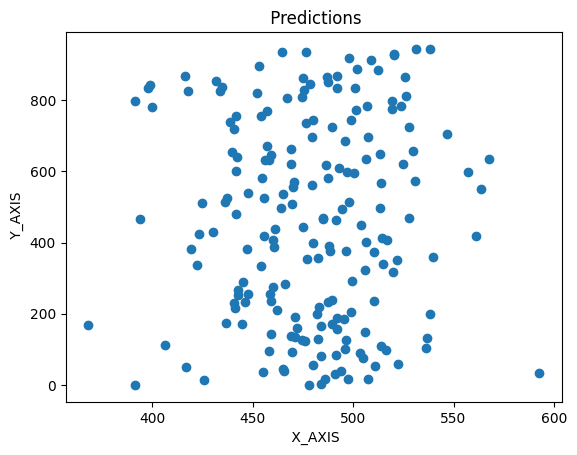

In [92]:
plt.scatter(y_pred , y_test)
plt.xlabel(" X_AXIS")
plt.ylabel(" Y_AXIS")
plt.title(" Predictions")
plt.show()